In [2]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
parent_dir = os.path.dirname(os.environ["GTE_DIR"].replace("Glaciation_time_estimator",""))
GTE_DIR=os.environ["GTE_DIR"]
sys.path.insert(0, parent_dir)
from Glaciation_time_estimator.Data_postprocessing.Job_result_fp_generator import generate_tracking_filenames
from Glaciation_time_estimator.Auxiliary_func.config_reader import read_config

In [3]:
config = read_config(
    os.path.join(GTE_DIR,'configs/2022_tracking/01_01.yaml'))
analyze_year=True
year=2022
glac_threshold=0.4
global global_rmse
global_rmse = config["Global_sqrt_mse"]
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
temperature_palette = ['#eff3ff','#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
red_temperature_palette  = ['#fee5d9','#fcbba1','#fc9272','#fb6a4a','#de2d26','#a50f15']

In [4]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'DJF'
    elif month in [3, 4, 5]:
        return 'MAM'
    elif month in [6, 7, 8]:
        return 'JJA'
    else:
        return 'SON'
if os.uname()[1]=="n2o":
    combined_cloud_df = pd.read_parquet(f"/wolke_scratch/dnikolo/Final_results/{year}_all.parquet")
    glaciations_df = pd.read_parquet(f"/wolke_scratch/dnikolo/Final_results/{year}_glac_04.parquet")
if os.uname()[1][:3]=="eu-":
    combined_cloud_df = pd.read_parquet(f"/cluster/work/climate/dnikolo/Cloud_analysis/full_years/{year}_all.parquet")
    glaciations_df = pd.read_parquet(f"/cluster/work/climate/dnikolo/Cloud_analysis/full_years/{year}_glac_{int(glac_threshold*10):02}_thresh.parquet")

    
combined_cloud_df['Season'] = combined_cloud_df['track_start_time'].dt.month.apply(month_to_season)
glaciations_df["Radius [km]"]=np.sqrt(glaciations_df["avg_size[km]"]/np.pi)
glaciations_df['Season'] = glaciations_df['track_start_time'].dt.month.apply(month_to_season)
for i,row in glaciations_df.iterrows():
    glaciations_df.loc[i, "Glaciation IF Maximum"] = row["ice_frac_hist"][int(row["Glac_peak_ind"])]

combined_cloud_df=combined_cloud_df[~combined_cloud_df.is_large_pix_cloud]
combined_cloud_df = combined_cloud_df[(combined_cloud_df.avg_lat >30) | (combined_cloud_df.avg_lat<-30)]

glaciations_df=glaciations_df[~glaciations_df.is_large_pix_cloud]
glaciations_df = glaciations_df[(glaciations_df.avg_lat >30) | (glaciations_df.avg_lat<-30)]

glaciating_clouds = glaciations_df.drop_duplicates(subset="Cloud_ID",keep="first")



In [5]:
glaciations_df["Glaciation rate"] = glaciations_df["Magnitude"] / glaciations_df["Glaciation time [h]"]

# Assigning size bins with custom labels
glaciations_df["Size bin"] = pd.cut(
    glaciations_df["avg_size[km]"],
    bins=[1000, 2000, 5000, 10000, np.inf],
    labels=["Small", "Medium", "Large", "Very Large"]
)

# Assigning lifetime bins with custom labels
glaciations_df["Lifetime bin"] = pd.cut(
    glaciations_df["Lifetime [h]"],
    bins=[0, 1, 2, 5, np.inf],
    labels=["Very Short", "Short", "Medium", "Long"])

glaciations_df["Magnitude bin"] =pd.cut(
    glaciations_df["Magnitude"],
    bins=[0.4, 0.6, 0.8, 1],
    labels=["Small", "Medium", "Full"])
glaciating_clouds = glaciations_df.drop_duplicates(subset="Cloud_ID",keep="first")
# Velry large long lived clouds
vlll_glaciations = glaciations_df[(glaciations_df["Lifetime bin"]=="Long") & (glaciations_df["Size bin"]=="Very Large")]
vlll_clouds = glaciating_clouds[(glaciating_clouds["Lifetime bin"]=="Long") & (glaciating_clouds["Size bin"]=="Very Large")]
linear_glac=glaciations_df[(glaciations_df["Linear"]==True) ]

Distribution of post-glaciation IF

/tmp/ipykernel_30132/32869689.py:54: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  std_df = hist_df_month.groupby(level="Temp", axis=1).std()


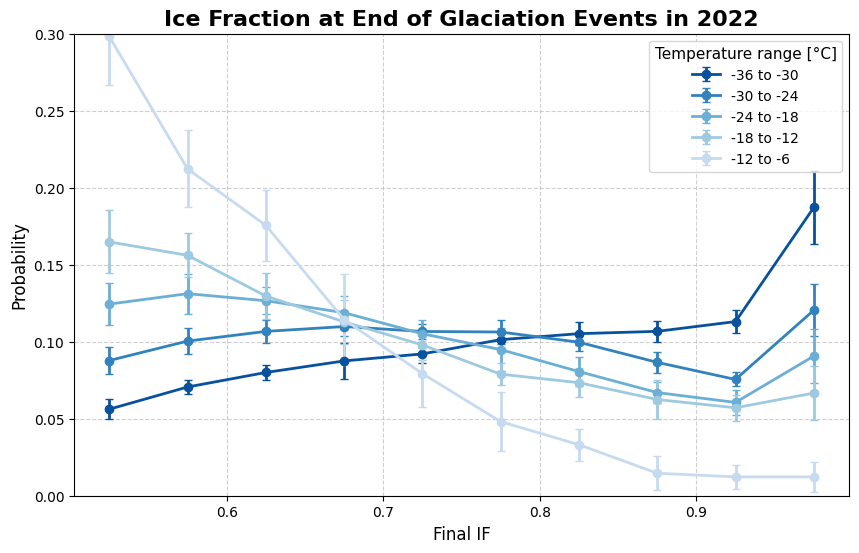

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Setup Parameters ---
binwidth = 0.05
bins = np.arange(0.5, 1 + binwidth, binwidth)

# Generate labels for temperature ranges (assuming config exists)
labels = [f'{config["min_temp_arr"][i]} to {config["max_temp_arr"][i]}' 
          for i in range(len(config["min_temp_arr"]))]

# --- Step 1. Compute Aggregated Histogram ---
# Group by min_temp and compute histogram for "Glaciation IF Maximum"
grouped = glaciations_df.groupby("min_temp")["Glaciation IF Maximum"]
hist_data = {temp: np.histogram(data, bins=bins, density=True)[0] 
             for temp, data in grouped}
hist_df = pd.DataFrame(hist_data, index=bins[:-1])  # bins left edges as index

# --- Step 2. Compute Monthly Histograms & Standard Deviation ---
# Extract month from "track_start_time" (assumes valid datetime strings)
glaciations_df['month'] = pd.to_datetime(glaciations_df['track_start_time']).dt.month

# Group by both month and min_temp for the column "Glaciation IF Maximum"
grouped_month = glaciations_df.groupby(['month', 'min_temp'])["Glaciation IF Maximum"]
hist_data_month = {}
for (month, temp), data in grouped_month:
    hist, _ = np.histogram(data, bins=bins, density=True)
    hist_data_month[(month, temp)] = hist

# Compute bin centers
bin_centers = bins[:-1] + binwidth/2

# Create a DataFrame to hold monthly histograms.
# Each column is labeled "Month_{month}_Temp_{temp}"
hist_df_month = pd.DataFrame(index=bin_centers)
for (month, temp), hist in hist_data_month.items():
    col_name = f"Month_{month}_Temp_{temp}"
    # Normalize the histogram (if non-zero sum)
    normalized_hist = hist / hist.sum() if hist.sum() > 0 else hist
    hist_df_month[col_name] = normalized_hist

# Create a MultiIndex for the columns based on Month and Temperature
new_columns = []
for col in hist_df_month.columns:
    parts = col.split('_')  # Expected format: "Month_{month}_Temp_{temp}"
    month = int(parts[1])
    temp = float(parts[3])
    new_columns.append((month, temp))
hist_df_month.columns = pd.MultiIndex.from_tuples(new_columns, names=["Month", "Temp"])

# Group by temperature to compute the standard deviation across months for each bin
std_df = hist_df_month.groupby(level="Temp", axis=1).std()

# --- Step 3. Plot the Aggregated Histogram with Error Bars ---
# Use your preferred color palette; note that the original code reverses the color order.
num_lines = len(hist_df.columns)
colors = temperature_palette[1:]  # assuming temperature_palette is defined
colors = colors[::-1]  # Reverse order to match the original plotting order

plt.figure(figsize=(12, 6))
for i, (temp, color) in enumerate(zip(hist_df.columns, colors)):
    # Compute normalized aggregated histogram
    y_values = hist_df[temp] / hist_df[temp].sum()
    # Get the corresponding standard deviation (error bar) for this temperature
    y_err = std_df[temp] if temp in std_df.columns else np.zeros_like(y_values)
    
    # Plot using errorbar with capsize for visibility
    plt.errorbar(hist_df.index + binwidth/2, y_values, yerr=y_err, capsize=3,
                 label=labels[-i-1], color=color, linewidth=2, marker='o')

plt.xlabel("Final IF", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.title("Ice Fraction at End of Glaciation Events in 2022", fontsize=16, fontweight='bold')
plt.ylim(0, 0.3)
plt.legend(title="Temperature range [°C]", frameon=True, loc="upper right",
           fontsize=10, title_fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)

# Save the figure in PDF and PNG formats
filename = os.path.join(GTE_DIR, "Result_graphs/End_of_glaciation_IF_by_temp")
plt.savefig(filename + ".pdf", dpi=400, bbox_inches='tight')
plt.savefig(filename + ".png", dpi=400, bbox_inches='tight')
plt.show()


In [ ]:
(glaciations_df["Glaciation IF Maximum"]>0.9).mean()

0.17931015859871466

In [41]:
len(glaciations_df)

111098

/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


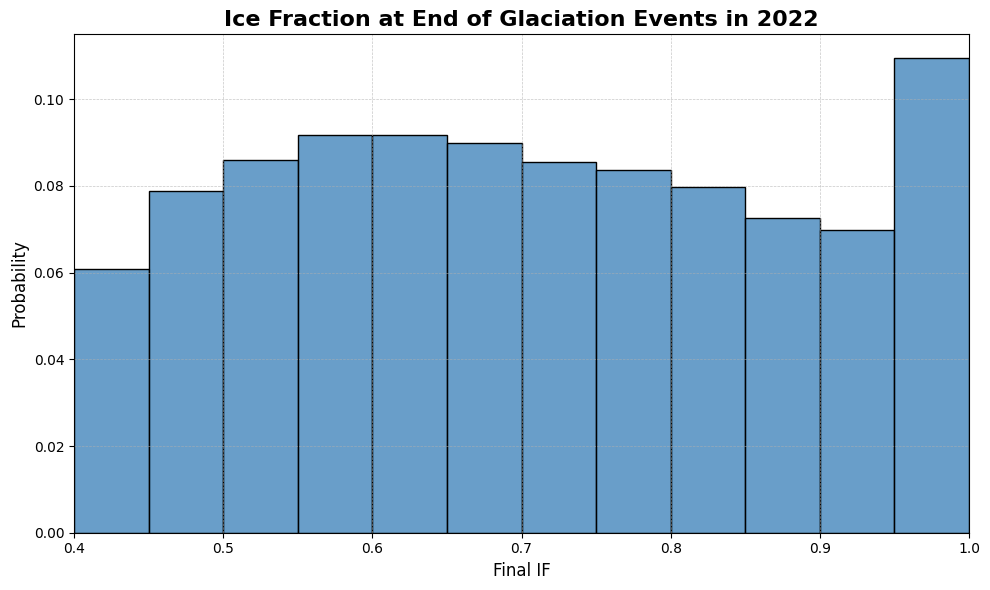

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Example data
data = glaciations_df["Glaciation IF Maximum"]

# Define the bin range and width
binrange = [0.4, 1.0]
binwidth = 0.05

# Create a NumPy array of bin edges
bins = np.arange(binrange[0], binrange[1] + binwidth, binwidth)
bins[-1]+=0.0001
# Now plot using the same bin parameters
f, ax = plt.subplots(figsize=(12, 6))
sns.histplot(data=data, bins=bins,
             color=classifiacation_palette[1], stat="probability", ax=ax)

ax.set_title("Ice Fraction at End of Glaciation Events in 2022", fontsize=16, weight="bold")
ax.set_xlabel("Final IF", fontsize=12)
ax.set_ylabel("Probability", fontsize=12)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
ax.set_xlim(0.4, 1)
plt.tight_layout()
filename = os.path.join(GTE_DIR,"Result_graphs/End_of_glaciation_IF")
plt.savefig(filename + ".pdf", dpi=400, bbox_inches='tight')
plt.savefig(filename + ".png", dpi=400, bbox_inches='tight')



/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


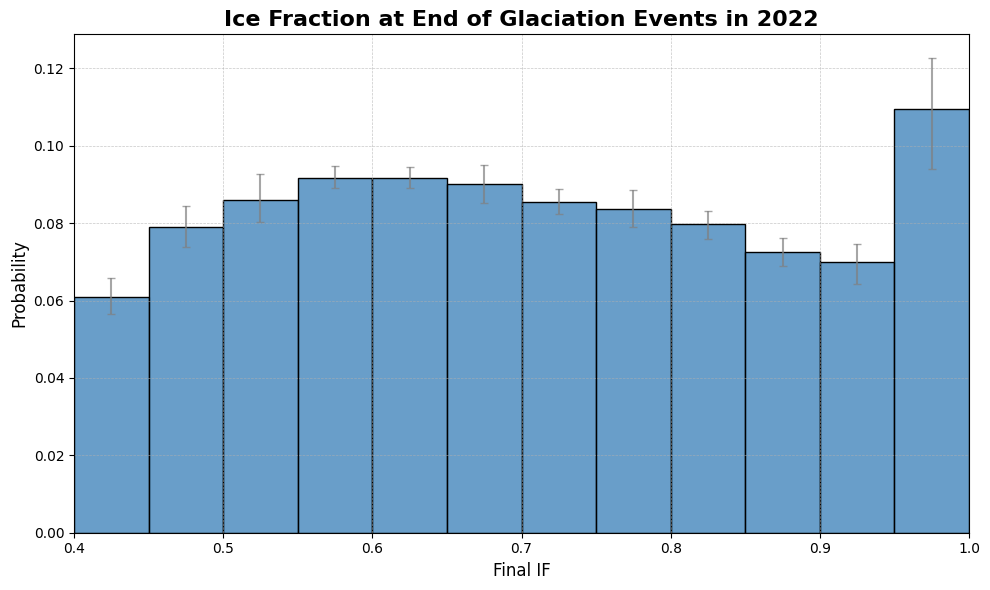

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1. Define bins ---
binrange = [0.4, 1.0]
binwidth = 0.05
bins = np.arange(binrange[0], binrange[1] + binwidth, binwidth)
bins[-1] += 0.0001  # Ensure the last bin captures 1.0
bin_centers = bins[:-1] + binwidth/2

# --- Step 2. Extract month from track_start_time ---
glaciations_df['month'] = pd.to_datetime(glaciations_df['track_start_time']).dt.month

# --- Step 3. Compute monthly histograms ---
# We'll compute a histogram for each month, then normalize to get probabilities.
monthly_hist_data = {}
for month, group in glaciations_df.groupby('month'):
    data = group["Glaciation IF Maximum"]
    counts, _ = np.histogram(data, bins=bins)
    total = counts.sum()
    # Normalize counts to probabilities (if total > 0)
    prob = counts / total if total > 0 else counts
    monthly_hist_data[month] = prob

# --- Step 4. Create a DataFrame with monthly histogram data ---
# Rows: bins (indexed by bin_centers), Columns: month
monthly_hist_df = pd.DataFrame(monthly_hist_data, index=bin_centers)

# --- Step 5. Compute mean and standard deviation across months for each bin ---
mean_prob = monthly_hist_df.mean(axis=1)
std_prob = monthly_hist_df.std(axis=1)

# --- Step 6. Plot with error bars ---
plt.figure(figsize=(12, 6))
sns.histplot(data= glaciations_df["Glaciation IF Maximum"], bins=bins,
             color=classifiacation_palette[1], stat="probability")
plt.errorbar(bin_centers, mean_prob, yerr=std_prob, linestyle="", capsize=3,
             color='gray',
            alpha=0.7)

plt.title("Ice Fraction at End of Glaciation Events in 2022", fontsize=16, weight="bold")
plt.xlabel("Final IF", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.xlim(0.4, 1)
plt.tight_layout()

filename = os.path.join(GTE_DIR, "Result_graphs/End_of_glaciation_IF")
plt.savefig(filename + ".pdf", dpi=400, bbox_inches='tight')
plt.savefig(filename + ".png", dpi=400, bbox_inches='tight')
plt.show()


Distribution of glaciation magnitudes

/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/wolke_scratch/dnikolo/flex_trkr_env/li

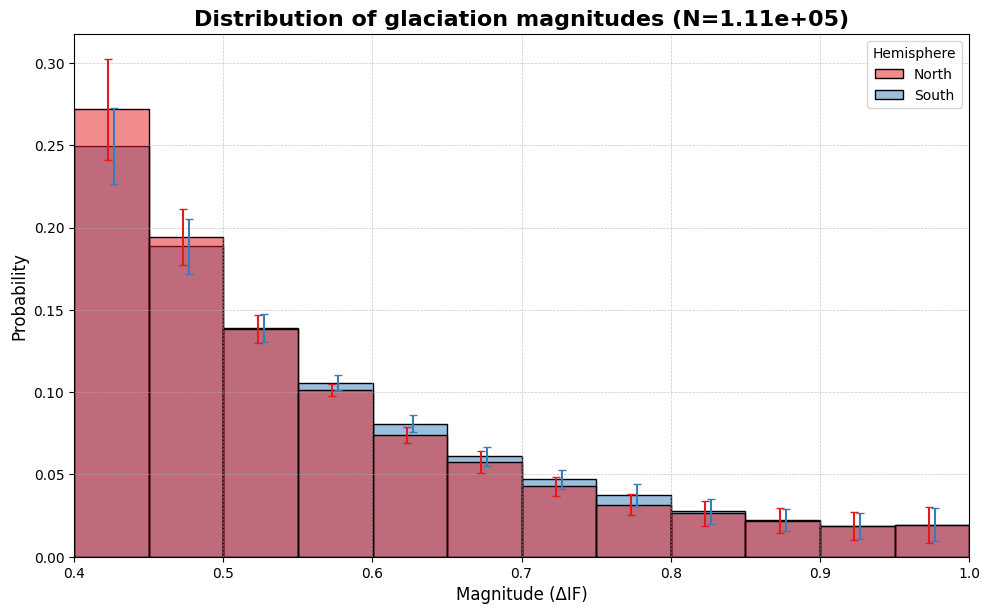

In [ ]:
# sns.histplot(glaciations_df,x="Magnitude",binwidth=0.05,stat="probability",hue="Hemisphere", palette=classifiacation_palette,common_norm=False)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Parameters and Bins ---
bins = np.arange(0, 1.001, 0.05) + 0.0001  # bins as defined
bin_centers = bins[:-1] + 0.05/2       # centers of the bins

# --- Add Month Column ---
# Ensure that track_start_time is parsed as datetime to extract month
glaciations_df['month'] = pd.to_datetime(glaciations_df['track_start_time']).dt.month

# --- Aggregated Histogram for Each Hemisphere ---
# We'll compute a histogram for each hemisphere
hemispheres = glaciations_df['Hemisphere'].unique()
agg_hist = {}
for hemi in hemispheres:
    data = glaciations_df.loc[glaciations_df['Hemisphere'] == hemi, "Magnitude"]
    hist, _ = np.histogram(data, bins=bins, density=True)
    # Normalize so that the sum equals 1 (to match stat="probability")
    agg_hist[hemi] = hist / hist.sum() if hist.sum() > 0 else hist

# --- Monthly Histograms for Error Bars ---
# Group the data by Hemisphere and month, then compute a normalized histogram for each group.
monthly_hist = {}
grouped = glaciations_df.groupby(['Hemisphere', 'month'])["Magnitude"]
for (hemi, month), data in grouped:
    hist, _ = np.histogram(data, bins=bins, density=True)
    # Normalize histogram to probability (if non-zero)
    monthly_hist[(hemi, month)] = hist / hist.sum() if hist.sum() > 0 else hist

# Create a DataFrame per hemisphere to hold monthly histograms.
# The index will be the bin centers, and each column will represent a different month.
monthly_df = {}
for hemi in hemispheres:
    # Extract all monthly histograms for this hemisphere
    data_dict = {month: monthly_hist[(hemi, month)]
                 for (h, month) in monthly_hist if h == hemi}
    # Create DataFrame with bin centers as the index
    monthly_df[hemi] = pd.DataFrame(data_dict, index=bin_centers)

# Compute the standard deviation across months for each bin (for each hemisphere)
std_err = {}
for hemi in hemispheres:
    std_err[hemi] = monthly_df[hemi].std(axis=1)

# --- Plotting ---
# First, plot the aggregated histogram using seaborn
f, ax = plt.subplots(figsize=(12, 6))
sns.histplot(data=glaciations_df, ax=ax, hue="Hemisphere", x="Magnitude",
             bins=bins, stat="probability", palette=classifiacation_palette[:2], legend=True,common_norm=False)
ax.set_xlim(0.4, 1)
ax.set_xlabel("Magnitude (ΔIF)", fontsize=12)
ax.set_ylabel("Probability", fontsize=12)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

# Overlay error bars for each hemisphere
colors = classifiacation_palette[:2]  # assuming the same order as in the hue
for i, hemi in enumerate(hemispheres):
    y_values = agg_hist[hemi]
    y_err = std_err[hemi].values  # standard deviation computed from monthly histograms
    if i==1:
        x_pos=bin_centers+0.002
    else:
        x_pos=bin_centers-0.002
    ax.errorbar(x_pos, y_values, yerr=y_err, color=colors[i], capsize=3,
                label=f"{hemi} error",linestyle='')
    
plt.tight_layout()
plt.title(f"Distribution of glaciation magnitudes (N={len(glaciations_df):.2e})",fontsize=16, fontweight="bold")
filename = os.path.join(GTE_DIR,"Result_graphs/Magnitude_of_glaciation")
plt.savefig(filename + ".pdf", dpi=400, bbox_inches='tight')
plt.savefig(filename + ".png", dpi=400, bbox_inches='tight')

/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


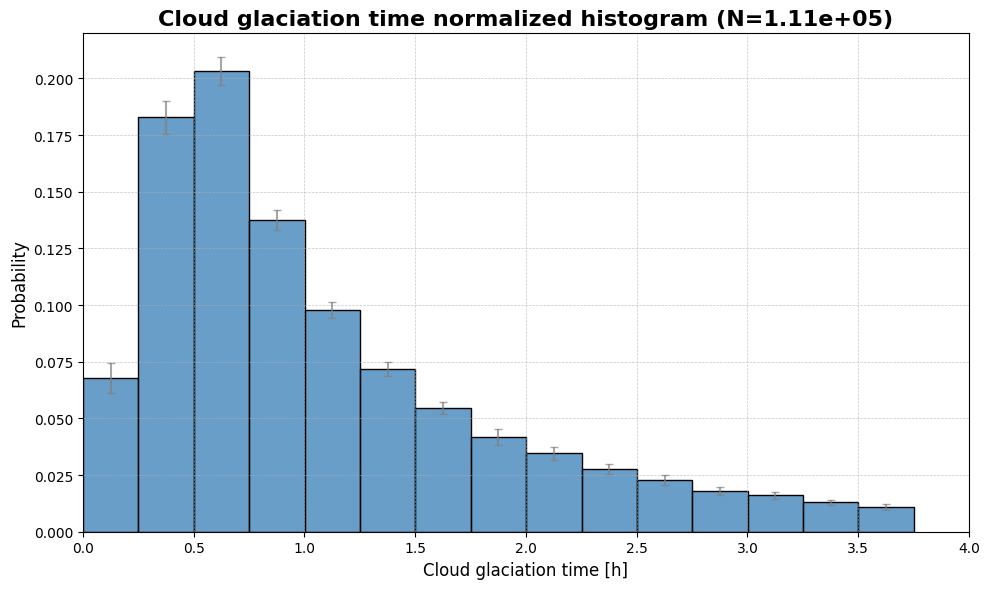

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Parameters and Bins ---
bins = np.arange(0, 4, 0.25) + 0.001  # Define bin edges (offset slightly to include edge values)
bin_centers = bins[:-1] + 0.25/2       # Compute centers of the bins

# --- Add Month Column ---
# Ensure that 'track_start_time' is parsed as datetime so that we can extract the month
glaciations_df['month'] = pd.to_datetime(glaciations_df['track_start_time']).dt.month

# --- Aggregated Histogram for Combined Distribution ---
# Combine data from both hemispheres
data_all = glaciations_df["Glaciation time [h]"]
hist_all, _ = np.histogram(data_all, bins=bins, density=True)
# Normalize so that the probabilities sum to 1
agg_hist = hist_all / hist_all.sum() if hist_all.sum() > 0 else hist_all

# --- Monthly Histograms for Error Bars (Combined) ---
# Group the data by month only, ignoring Hemisphere
monthly_hist = {}
for month, group in glaciations_df.groupby('month'):
    data = group["Glaciation time [h]"]
    hist, _ = np.histogram(data, bins=bins, density=True)
    monthly_hist[month] = hist / hist.sum() if hist.sum() > 0 else hist

# Create a DataFrame where rows correspond to bin centers and columns to each month
monthly_hist_df = pd.DataFrame(monthly_hist, index=bin_centers)
# Compute the standard deviation across months for each bin
std_err = monthly_hist_df.std(axis=1)

# --- Plotting ---
f, ax = plt.subplots(figsize=(12, 6))
# Plot the aggregated histogram using seaborn
sns.histplot(data=glaciations_df, ax=ax, x="Glaciation time [h]",
             bins=bins, stat="probability", color=classifiacation_palette[1],
             legend=False, common_norm=False)

ax.set_xlim(0, 4)
ax.set_xlabel("Cloud glaciation time [h]", fontsize=12)
ax.set_ylabel("Probability", fontsize=12)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.title(f"Cloud glaciation time normalized histogram (N={len(glaciations_df):.2e})",
          fontsize=16, fontweight="bold")

# Overlay error bars based on the monthly standard deviation
ax.errorbar(bin_centers, agg_hist, yerr=std_err, color="gray",alpha=0.7,
            capsize=3, linestyle='')

plt.tight_layout()
filename = os.path.join(GTE_DIR, "Result_graphs/CGT_stistics.png")
plt.savefig(filename, dpi=400, bbox_inches='tight')
plt.show()


/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/wolke_scratch/dnikolo/flex_trkr_env/li

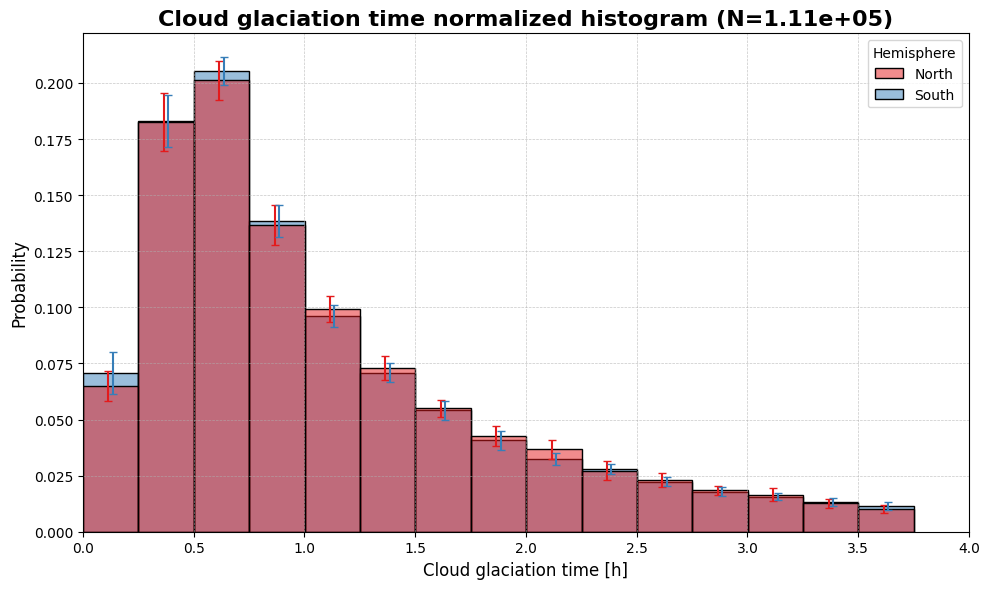

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Parameters and Bins ---
bins = np.arange(0, 4, 0.25) + 0.001  # bins as defined
bin_centers = bins[:-1] + 0.25/2       # centers of the bins

# --- Add Month Column ---
# Ensure that track_start_time is parsed as datetime to extract month
glaciations_df['month'] = pd.to_datetime(glaciations_df['track_start_time']).dt.month

# --- Aggregated Histogram for Each Hemisphere ---
# We'll compute a histogram for each hemisphere
hemispheres = glaciations_df['Hemisphere'].unique()
agg_hist = {}
for hemi in hemispheres:
    data = glaciations_df.loc[glaciations_df['Hemisphere'] == hemi, "Glaciation time [h]"]
    hist, _ = np.histogram(data, bins=bins, density=True)
    # Normalize so that the sum equals 1 (to match stat="probability")
    agg_hist[hemi] = hist / hist.sum() if hist.sum() > 0 else hist

# --- Monthly Histograms for Error Bars ---
# Group the data by Hemisphere and month, then compute a normalized histogram for each group.
monthly_hist = {}
grouped = glaciations_df.groupby(['Hemisphere', 'month'])["Glaciation time [h]"]
for (hemi, month), data in grouped:
    hist, _ = np.histogram(data, bins=bins, density=True)
    # Normalize histogram to probability (if non-zero)
    monthly_hist[(hemi, month)] = hist / hist.sum() if hist.sum() > 0 else hist

# Create a DataFrame per hemisphere to hold monthly histograms.
# The index will be the bin centers, and each column will represent a different month.
monthly_df = {}
for hemi in hemispheres:
    # Extract all monthly histograms for this hemisphere
    data_dict = {month: monthly_hist[(hemi, month)]
                 for (h, month) in monthly_hist if h == hemi}
    # Create DataFrame with bin centers as the index
    monthly_df[hemi] = pd.DataFrame(data_dict, index=bin_centers)

# Compute the standard deviation across months for each bin (for each hemisphere)
std_err = {}
for hemi in hemispheres:
    std_err[hemi] = monthly_df[hemi].std(axis=1)

# --- Plotting ---
# First, plot the aggregated histogram using seaborn
f, ax = plt.subplots(figsize=(12, 6))
sns.histplot(data=glaciations_df, ax=ax, hue="Hemisphere", x="Glaciation time [h]",
             bins=bins, stat="probability", palette=classifiacation_palette[:2], legend=True,common_norm=False)
ax.set_xlim(0, 4)
ax.set_xlabel("Cloud glaciation time [h]", fontsize=12)
ax.set_ylabel("Probability", fontsize=12)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.title(f"Cloud glaciation time normalized histogram (N={len(glaciations_df):.2e})",fontsize=16, fontweight="bold")

# Overlay error bars for each hemisphere
colors = classifiacation_palette[:2]  # assuming the same order as in the hue
for i, hemi in enumerate(hemispheres):
    y_values = agg_hist[hemi]
    y_err = std_err[hemi].values  # standard deviation computed from monthly histograms
    if i==1:
        x_pos=bin_centers+0.01
    else:
        x_pos=bin_centers-0.01
    ax.errorbar(x_pos, y_values, yerr=y_err, color=colors[i], capsize=3,
                label=f"{hemi} error",linestyle='')
    
plt.tight_layout()
plt.savefig(os.path.join(GTE_DIR, "Result_graphs/CGT_stistics_by_hemisphere.png"), dpi=400, bbox_inches='tight')
plt.show()


Glaciation rate distribution lineplot

/tmp/ipykernel_30132/1576789328.py:49: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  std_df = hist_df_month.groupby(level="Temp", axis=1).std()


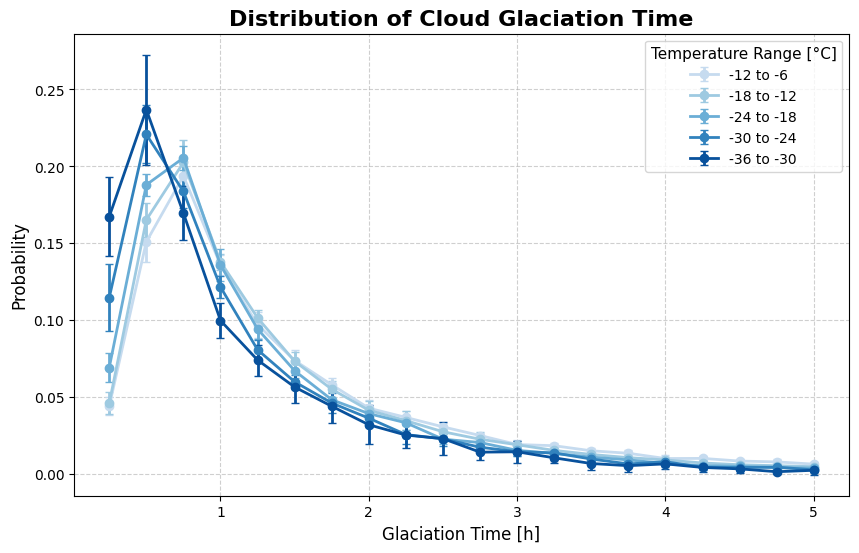

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Parameters & Labels ---
binwidth = 0.25
bins = np.arange(0.125, 5 + binwidth, binwidth)
labels = [f'{config["min_temp_arr"][i]} to {config["max_temp_arr"][i]}' 
          for i in range(len(config["min_temp_arr"]))]

# --- Step 1: Aggregated Histogram ---
grouped = glaciations_df.groupby("min_temp")["Glaciation time [h]"]
hist_data = {temp: np.histogram(data, bins=bins, density=True)[0] for temp, data in grouped}
hist_df = pd.DataFrame(hist_data, index=bins[:-1])  # using the left edges of bins as index

# --- Step 2: Monthly Histograms & Standard Deviation ---
# Extract month from "track_start_time" (assuming valid datetime format)
glaciations_df['month'] = pd.to_datetime(glaciations_df['track_start_time']).dt.month

# Group by month and min_temp for "Glaciation time [h]"
grouped_month = glaciations_df.groupby(['month', 'min_temp'])["Glaciation time [h]"]
hist_data_month = {}
for (month, temp), data in grouped_month:
    hist, _ = np.histogram(data, bins=bins, density=True)
    hist_data_month[(month, temp)] = hist

# Compute bin centers for consistent x-axis
bin_centers = bins[:-1] + binwidth/2

# Create a DataFrame to store monthly histograms.
# Columns are labeled "Month_{month}_Temp_{temp}" and values normalized (if non-zero).
hist_df_month = pd.DataFrame(index=bin_centers)
for (month, temp), hist in hist_data_month.items():
    col_name = f"Month_{month}_Temp_{temp}"
    normalized_hist = hist / hist.sum() if hist.sum() > 0 else hist
    hist_df_month[col_name] = normalized_hist

# Create a MultiIndex for the columns: level 0 = Month, level 1 = Temp.
new_columns = []
for col in hist_df_month.columns:
    parts = col.split('_')  # expected format: "Month_{month}_Temp_{temp}"
    month = int(parts[1])
    temp = float(parts[3])
    new_columns.append((month, temp))
hist_df_month.columns = pd.MultiIndex.from_tuples(new_columns, names=["Month", "Temp"])

# Group by temperature (the "Temp" level) to compute the standard deviation across months for each bin.
std_df = hist_df_month.groupby(level="Temp", axis=1).std()

# --- Step 3: Plotting with Error Bars ---
colors = temperature_palette[1:]  # assuming temperature_palette is defined

plt.figure(figsize=(12, 6))
for i, (temp, color) in enumerate(zip(hist_df.columns, colors)):
    # Compute the normalized aggregated histogram for each temperature group.
    y_values = hist_df[temp] / hist_df[temp].sum()
    # Use the computed standard deviation (error bar) for this temperature if available.
    y_err = std_df[temp] if temp in std_df.columns else np.zeros_like(y_values)
    
    plt.errorbar(hist_df.index + binwidth/2, y_values, yerr=y_err, capsize=3,
                 label=labels[i+1], color=color, linewidth=2, marker='o')

plt.xlabel("Glaciation Time [h]", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.title("Distribution of Cloud Glaciation Time", fontsize=16, fontweight='bold')
plt.legend(title="Temperature Range [°C]", frameon=True, loc="upper right", fontsize=10, title_fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [31]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use the same bin width and compute bins based on the global glaciation rates
binwidth = 0.5
glaciation_rates = glaciations_df["Glaciation rate"]
bins = np.arange(0, glaciation_rates.max() + binwidth, binwidth)

# Optionally, if you need labels as before, you can still generate them.
labels = [f'{config["min_temp_arr"][i]} to {config["max_temp_arr"][i]}' 
          for i in range(len(config["min_temp_arr"]))]

# First, extract the month from the "track_start_time" column.
# Assuming the "track_start_time" column is in a format recognizable by pd.to_datetime.
glaciations_df['month'] = pd.to_datetime(glaciations_df['track_start_time']).dt.month

# Group the data by both month and the temperature (min_temp)
grouped = glaciations_df.groupby(['month', 'min_temp'])['Glaciation rate']

# Create a dictionary to store histogram arrays for each (month, temperature)
hist_data = {}
for (month, temp), data in grouped:
    # Compute histogram with probability density (density=True)
    hist, _ = np.histogram(data, bins=bins, density=True)
    # Store the histogram using a tuple key (month, temp)
    hist_data[(month, temp)] = hist

# Calculate bin centers for plotting or as index values
bin_centers = bins[:-1] + binwidth/2

# Now, create a new DataFrame where the index is the bin centers
# and each column corresponds to a specific (month, temperature) combination.
# Here, we label columns as "Month_{month}_Temp_{temp}".
hist_df_month = pd.DataFrame(index=bin_centers)
for (month, temp), hist in hist_data.items():
    col_name = f"Month_{month}_Temp_{temp}"
    # It might be useful to normalize the histogram values as you did previously (divide by the sum)
    normalized_hist = hist / hist.sum() if hist.sum() > 0 else hist
    hist_df_month[col_name] = normalized_hist

# hist_df_month now holds the histogram values for each bin (index) for every (month, temperature) group.
print(hist_df_month.head())


      Month_1_Temp_-36  Month_1_Temp_-30  Month_1_Temp_-24  Month_1_Temp_-18  \
0.25          0.545351          0.487098          0.446260          0.412762   
0.75          0.345351          0.381501          0.363922          0.333998   
1.25          0.061803          0.065899          0.084852          0.095713   
1.75          0.031187          0.046447          0.067253          0.092722   
2.25          0.009728          0.011513          0.014456          0.029910   

      Month_1_Temp_-12  Month_2_Temp_-36  Month_2_Temp_-30  Month_2_Temp_-24  \
0.25          0.422492          0.510209          0.460513          0.455352   
0.75          0.300912          0.358377          0.390870          0.376700   
1.25          0.094225          0.080366          0.091969          0.080426   
1.75          0.091185          0.036911          0.036321          0.053814   
2.25          0.048632          0.007592          0.010996          0.015967   

      Month_2_Temp_-18  Month_2_Temp_-

In [32]:
import re

# Assume hist_df_month is the DataFrame with histogram values computed earlier.
# Its columns are like "Month_{month}_Temp_{temp}"
# Let's extract month and temperature and create a MultiIndex.
new_columns = []
for col in hist_df_month.columns:
    # Split the column name, e.g., "Month_3_Temp_5" -> month = 3, temp = 5
    parts = col.split('_')
    # parts[1] is month and parts[3] is temperature
    month = int(parts[1])
    # Convert temperature to a number (int or float) as needed.
    temp = float(parts[3])
    new_columns.append((month, temp))

# Set the new MultiIndex for the columns
hist_df_month.columns = pd.MultiIndex.from_tuples(new_columns, names=["Month", "Temp"])

# Now, for each temperature range (grouping by the 'Temp' level),
# calculate the standard deviation across months for each bin.
std_df = hist_df_month.groupby(level="Temp", axis=1).std()

print(std_df.head())


Temp     -36.0     -30.0     -24.0     -18.0     -12.0
0.25  0.020758  0.026058  0.014025  0.028827  0.045738
0.75  0.011691  0.018058  0.019824  0.014205  0.028555
1.25  0.009064  0.007915  0.011417  0.014104  0.012880
1.75  0.004307  0.004606  0.006774  0.008723  0.014378
2.25  0.001669  0.003323  0.003321  0.007052  0.012297


/tmp/ipykernel_30132/3233264.py:21: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  std_df = hist_df_month.groupby(level="Temp", axis=1).std()


/tmp/ipykernel_40568/1980504878.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  linear_glac['month'] = pd.to_datetime(linear_glac['track_start_time']).dt.month
/tmp/ipykernel_40568/1980504878.py:55: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  std_df = hist_df_month.groupby(level="Temp", axis=1).std()


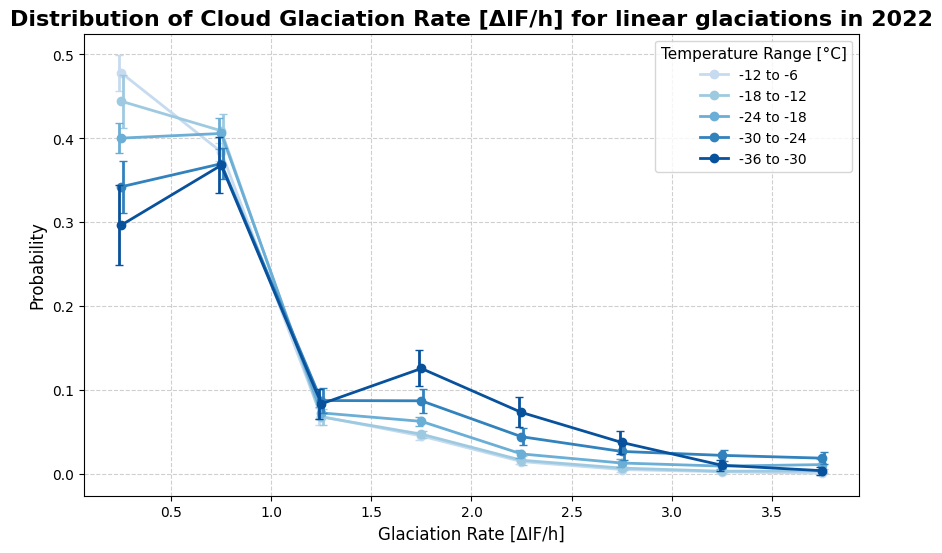

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Step 1. Compute aggregated histogram (as before) ---
binwidth = 0.5
glaciation_rates = linear_glac["Glaciation rate"]
bins = np.arange(0, glaciation_rates.max() + binwidth, binwidth)

# Generate labels for temperature ranges (assuming config exists)
labels = [f'{config["min_temp_arr"][i]} to {config["max_temp_arr"][i]}' 
          for i in range(len(config["min_temp_arr"]))]

# Group by min_temp and compute histogram (aggregated over all months)
grouped = linear_glac.groupby("min_temp")["Glaciation rate"]
hist_data = {temp: np.histogram(data, bins=bins, density=True)[0] 
             for temp, data in grouped}
hist_df = pd.DataFrame(hist_data, index=bins[:-1])  # index is left edge of bins

# --- Step 2. Compute monthly histograms and standard deviations ---
# Extract month from "track_start_time"
linear_glac['month'] = pd.to_datetime(linear_glac['track_start_time']).dt.month

# Group by month and min_temp to compute histogram for each (month, temperature)
grouped_month = linear_glac.groupby(['month', 'min_temp'])['Glaciation rate']
hist_data_month = {}
for (month, temp), data in grouped_month:
    hist, _ = np.histogram(data, bins=bins, density=True)
    hist_data_month[(month, temp)] = hist

# Calculate bin centers for consistent indexing
bin_centers = bins[:-1] + binwidth/2

# Create a DataFrame with monthly histograms.
# Columns will be labeled as "Month_{month}_Temp_{temp}"
hist_df_month = pd.DataFrame(index=bin_centers)
for (month, temp), hist in hist_data_month.items():
    col_name = f"Month_{month}_Temp_{temp}"
    # Normalize histogram if desired (as in your original code)
    normalized_hist = hist / hist.sum() if hist.sum() > 0 else hist
    hist_df_month[col_name] = normalized_hist

# Create a MultiIndex for columns based on month and temperature
new_columns = []
for col in hist_df_month.columns:
    # Expecting format: "Month_{month}_Temp_{temp}"
    parts = col.split('_')
    month = int(parts[1])
    temp = float(parts[3])
    new_columns.append((month, temp))
hist_df_month.columns = pd.MultiIndex.from_tuples(new_columns, names=["Month", "Temp"])

# For each temperature range, compute standard deviation across months for each bin.
std_df = hist_df_month.groupby(level="Temp", axis=1).std()

# --- Step 3. Plot the aggregated histogram with error bars ---
# Set your color palette (skipping first color if needed)
num_lines = len(hist_df.columns)
colors = temperature_palette[1:]  # or use any colormap

plt.figure(figsize=(12, 6))
for i, (temp, color) in enumerate(zip(hist_df.columns, colors)):
    # Aggregated normalized histogram for this temperature group
    y_values = hist_df[temp] / hist_df[temp].sum()
    
    # Error bars: standard deviation for this temperature from std_df.
    # We assume that the 'temp' value in hist_df matches the "Temp" level in std_df.
    if temp in std_df.columns:
        y_err = std_df[temp]
    else:
        y_err = np.zeros_like(y_values)
    plt.plot(hist_df.index + binwidth/2 , y_values,
                 label=labels[i+1], color=color, linewidth=2, marker='o')
    plt.errorbar(hist_df.index + binwidth/2 +(i%2)*0.01-((i+1)%2)*0.01, y_values, yerr=y_err, color=color, linewidth=2, capsize=3,linestyle='')

plt.xlabel("Glaciation Rate [ΔIF/h]", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.title("Distribution of Cloud Glaciation Rate [ΔIF/h] for linear glaciations in 2022", fontsize=16, fontweight='bold')
plt.legend(title="Temperature Range [°C]", frameon=True, loc="upper right", fontsize=10, title_fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig(os.path.join(GTE_DIR, 'Result_graphs/Linear_glaciation_Rate_dist_line.png'), dpi=400, bbox_inches='tight')
plt.show()


/tmp/ipykernel_30132/3289702459.py:55: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  std_df = hist_df_month.groupby(level="Temp", axis=1).std()


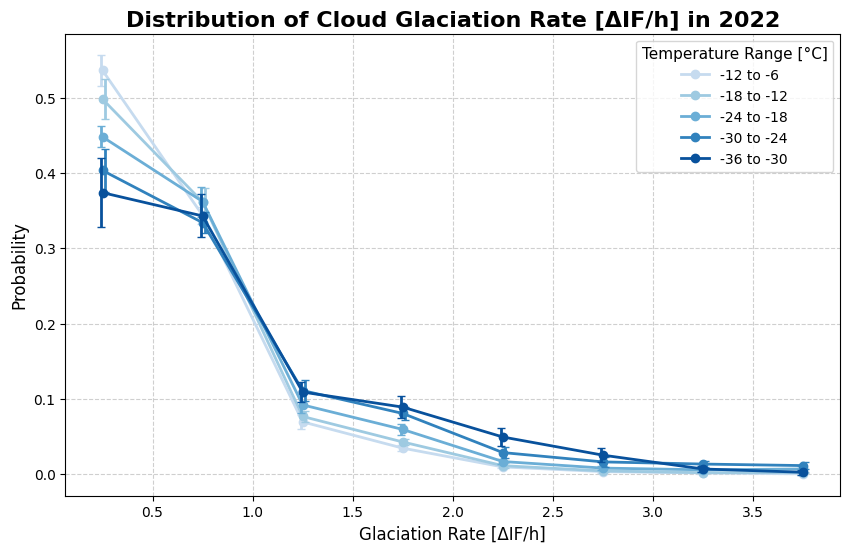

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Step 1. Compute aggregated histogram (as before) ---
binwidth = 0.5
glaciation_rates = glaciations_df["Glaciation rate"]
bins = np.arange(0, glaciation_rates.max() + binwidth, binwidth)

# Generate labels for temperature ranges (assuming config exists)
labels = [f'{config["min_temp_arr"][i]} to {config["max_temp_arr"][i]}' 
          for i in range(len(config["min_temp_arr"]))]

# Group by min_temp and compute histogram (aggregated over all months)
grouped = glaciations_df.groupby("min_temp")["Glaciation rate"]
hist_data = {temp: np.histogram(data, bins=bins, density=True)[0] 
             for temp, data in grouped}
hist_df = pd.DataFrame(hist_data, index=bins[:-1])  # index is left edge of bins

# --- Step 2. Compute monthly histograms and standard deviations ---
# Extract month from "track_start_time"
glaciations_df['month'] = pd.to_datetime(glaciations_df['track_start_time']).dt.month

# Group by month and min_temp to compute histogram for each (month, temperature)
grouped_month = glaciations_df.groupby(['month', 'min_temp'])['Glaciation rate']
hist_data_month = {}
for (month, temp), data in grouped_month:
    hist, _ = np.histogram(data, bins=bins, density=True)
    hist_data_month[(month, temp)] = hist

# Calculate bin centers for consistent indexing
bin_centers = bins[:-1] + binwidth/2

# Create a DataFrame with monthly histograms.
# Columns will be labeled as "Month_{month}_Temp_{temp}"
hist_df_month = pd.DataFrame(index=bin_centers)
for (month, temp), hist in hist_data_month.items():
    col_name = f"Month_{month}_Temp_{temp}"
    # Normalize histogram if desired (as in your original code)
    normalized_hist = hist / hist.sum() if hist.sum() > 0 else hist
    hist_df_month[col_name] = normalized_hist

# Create a MultiIndex for columns based on month and temperature
new_columns = []
for col in hist_df_month.columns:
    # Expecting format: "Month_{month}_Temp_{temp}"
    parts = col.split('_')
    month = int(parts[1])
    temp = float(parts[3])
    new_columns.append((month, temp))
hist_df_month.columns = pd.MultiIndex.from_tuples(new_columns, names=["Month", "Temp"])

# For each temperature range, compute standard deviation across months for each bin.
std_df = hist_df_month.groupby(level="Temp", axis=1).std()

# --- Step 3. Plot the aggregated histogram with error bars ---
# Set your color palette (skipping first color if needed)
num_lines = len(hist_df.columns)
colors = temperature_palette[1:]  # or use any colormap

plt.figure(figsize=(12, 6))
for i, (temp, color) in enumerate(zip(hist_df.columns, colors)):
    # Aggregated normalized histogram for this temperature group
    y_values = hist_df[temp] / hist_df[temp].sum()
    
    # Error bars: standard deviation for this temperature from std_df.
    # We assume that the 'temp' value in hist_df matches the "Temp" level in std_df.
    if temp in std_df.columns:
        y_err = std_df[temp]
    else:
        y_err = np.zeros_like(y_values)
    plt.plot(hist_df.index + binwidth/2 , y_values,
                 label=labels[i+1], color=color, linewidth=2, marker='o')
    plt.errorbar(hist_df.index + binwidth/2 +(i%2)*0.01-((i+1)%2)*0.01, y_values, yerr=y_err, color=color, linewidth=2, capsize=3,linestyle='')

plt.xlabel("Glaciation Rate [ΔIF/h]", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.title("Distribution of Cloud Glaciation Rate [ΔIF/h] in 2022", fontsize=16, fontweight='bold')
plt.legend(title="Temperature Range [°C]", frameon=True, loc="upper right", fontsize=10, title_fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig(os.path.join(GTE_DIR, 'Result_graphs/Glaciation_Rate_dist_line.png'), dpi=400, bbox_inches='tight')
plt.show()


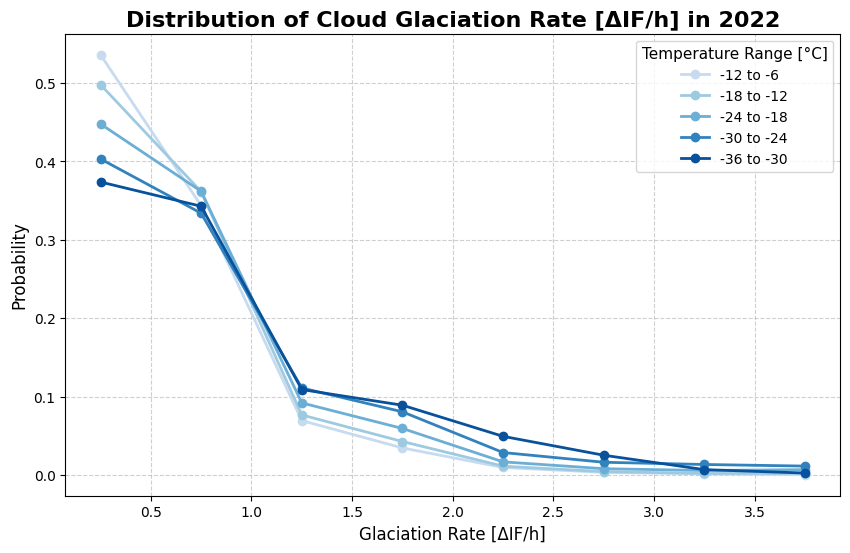

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Assuming vlll_glaciations is your dataframe
binwidth = 0.5

# Generate labels
labels = [f'{config["min_temp_arr"][i]} to {config["max_temp_arr"][i]}' 
          for i in range(len(config["min_temp_arr"]))]

# Compute histogram data
glaciation_rates = glaciations_df["Glaciation rate"]
bins = np.arange(0, glaciation_rates.max() + binwidth, binwidth)

# Group by min_temp and calculate probability density
grouped = glaciations_df.groupby("min_temp")["Glaciation rate"]
hist_data = {temp: np.histogram(data, bins=bins, density=True)[0] for temp, data in grouped}

# Convert to DataFrame for easier plotting
hist_df = pd.DataFrame(hist_data, index=bins[:-1])

# Set color palette
num_lines = len(hist_df.columns)
# colors = cm.viridis(np.linspace(0, 1, num_lines))  # Smooth gradient from viridis colormap
colors = temperature_palette[1:]
# Plot lineplot
plt.figure(figsize=(10, 6))

for i, (temp, color) in enumerate(zip(hist_df.columns, colors)):
    plt.plot(hist_df.index + binwidth/2, hist_df[temp] / hist_df[temp].sum(), 
             label=labels[i+1], color=color, linewidth=2, marker='o')
    # sns.scatterplot(x=hist_df.index + binwidth/2,y= hist_df[temp] / hist_df[temp].sum(), 
    #          label=labels[i], color=color)

# Labels and Title
plt.xlabel("Glaciation Rate [ΔIF/h]", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.title("Distribution of Cloud Glaciation Rate [ΔIF/h] in 2022", fontsize=16, fontweight='bold')

# Legend
plt.legend(title="Temperature Range [°C]", frameon=True, loc="upper right", fontsize=10, title_fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)  # Dashed grid lines for better visibility
# plt.savefig(os.path.join(GTE_DIR,'Result_graphs/Glaciation_Rate_dist_line.png'),dpi=400)
# Show plot
plt.show()


In [35]:
binwidth = 0.5
bins = np.arange(0, glaciations_df["Glaciation rate"].max() + binwidth, binwidth)
bin_centers = (bins[:-1] + bins[1:]) / 2

In [36]:
monthly_dist_north = pd.DataFrame(columns=bin_centers)
monthly_dist_south = pd.DataFrame(columns=bin_centers)
northern_glac_kernel = (glaciations_df["Hemisphere"] == "North")
southern_glac_kernel = (glaciations_df["Hemisphere"] == "South")
for n_month in range(1, 13):
    print(n_month)
    glac_month_kernel = (
        glaciations_df['track_start_time'].dt.month == n_month)
    north_data=glaciations_df[glac_month_kernel & northern_glac_kernel]["Glaciation rate"]
    south_data=glaciations_df[glac_month_kernel & southern_glac_kernel]["Glaciation rate"]
    if (len(north_data) != 0) and (len(south_data) != 0):
        # print(north_data)
        occurrence_rate_north = np.histogram(north_data, bins=bins, density=True)[0]
        occurrence_rate_south = np.histogram(south_data, bins=bins, density=True)[0]
        # print(occurrence_rate_north)
        monthly_dist_north.loc[n_month, bin_centers] = occurrence_rate_north
        monthly_dist_south.loc[n_month, bin_centers] = occurrence_rate_south
    # else:
    #     daily_rate_north.loc[n_month] = 0
    #     daily_rate_south.loc[n_month] = 0
monthly_dist_north = monthly_dist_north.fillna(0)
monthly_dist_south = monthly_dist_south.fillna(0)

1
2
3
4
5
6
7
8
9
10
11
12


/tmp/ipykernel_30132/2605198948.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  monthly_dist_north = monthly_dist_north.fillna(0)
/tmp/ipykernel_30132/2605198948.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  monthly_dist_south = monthly_dist_south.fillna(0)


In [37]:
error_dist_north = []
error_dist_south = []
for bin in bin_centers:
    ser_north = monthly_dist_north[bin]
    ser_south = monthly_dist_south[bin]
    uppper_quantile_value_north = ser_north.quantile(q=0.75)
    lower_quantile_value_north= ser_north.quantile(q=0.25)
    uppper_quantile_value_south = ser_south.quantile(q=0.75)
    lower_quantile_value_south = ser_south.quantile(q=0.25)
    # print(ser_north)
    error_dist_north.append(ser_north.std())
    error_dist_south.append(ser_south.std())
# error_dist_north = error_dist_north[::-1]
# error_dist_south = error_dist_south[::-1]


In [38]:
# np.sqrt(np.array(error_dist_north)**2+np.array(error_dist_south)**2)

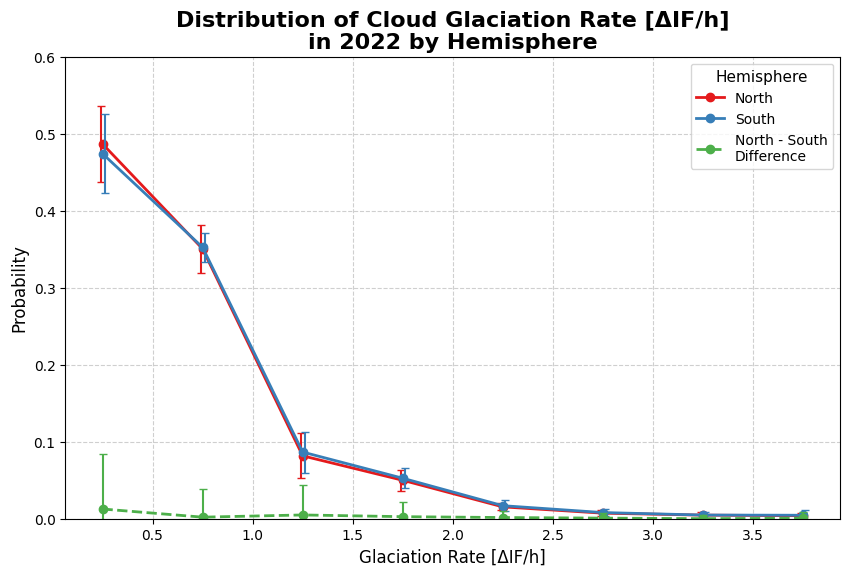

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Define bin width and bins
binwidth = 0.5
glaciation_rates = glaciations_df["Glaciation rate"]
bins = np.arange(0, glaciation_rates.max() + binwidth, binwidth)

# North Hemisphere: compute histogram and normalize so that the sum of probabilities equals 1
north_data = glaciations_df[glaciations_df["Hemisphere"]=="North"]["Glaciation rate"]
north_hist = np.histogram(north_data, bins=bins, density=True)[0]
north_hist_norm = north_hist / north_hist.sum()

# South Hemisphere: compute histogram and normalize
south_data = glaciations_df[glaciations_df["Hemisphere"]=="South"]["Glaciation rate"]
south_hist = np.histogram(south_data, bins=bins, density=True)[0]
south_hist_norm = south_hist / south_hist.sum()

# Plot the normalized histograms for both hemispheres
plt.figure(figsize=(12, 6))
bin_centers = bins[:-1] + binwidth/2

plt.plot(bin_centers, north_hist_norm, label="North", color=classifiacation_palette[0], linewidth=2, marker='o')
plt.errorbar(bin_centers-0.01, north_hist_norm, yerr=error_dist_north, color=classifiacation_palette[0], capsize=3, linestyle='')
plt.plot(bin_centers, south_hist_norm, label="South", color=classifiacation_palette[1], linewidth=2, marker='o')
plt.errorbar(bin_centers+0.01, south_hist_norm, yerr=error_dist_south, color=classifiacation_palette[1], capsize=3, linestyle='')
plt.plot(bin_centers, abs(north_hist_norm - south_hist_norm), label="North - South\nDifference", color=classifiacation_palette[2], linewidth=2, marker='o',linestyle="--")
plt.errorbar(bin_centers, abs(north_hist_norm - south_hist_norm), yerr=np.sqrt(np.array(error_dist_north)**2+np.array(error_dist_south)**2), color=classifiacation_palette[2], capsize=3, linestyle='')

# Set labels and title
plt.xlabel("Glaciation Rate [ΔIF/h]", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.title("Distribution of Cloud Glaciation Rate [ΔIF/h]\nin 2022 by Hemisphere", fontsize=16, fontweight='bold')

# Legend and grid
legend = plt.legend(title="Hemisphere", frameon=True, loc="upper right", 
                    fontsize=10, title_fontsize=11, alignment="center")

# Center-align each legend text
# plt.setp(legend.get_texts(), multialignment="center")
plt.grid(True, linestyle="--", alpha=0.6)
plt.ylim(0,0.6)
# Save and show the plot (adjust the directory as needed)
plt.savefig(os.path.join(GTE_DIR, 'Result_graphs/Glaciation_Rate_dist_line_by_hemisphere.png'), dpi=400)
plt.show()